# DD2525 Analysis

Todo

In [1]:
import json
import pathlib
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_dir = pathlib.Path("../results")
rows = []
tot_num_revisions = 0
for repo_dir in sorted(results_dir.iterdir()):
    # iterate over all versions of this repo
    for json_file in repo_dir.glob("*.json"):
        # check if an error.log exists, if it does, then we skip this version (since it failed)
        if (repo_dir / f"{json_file.stem}.error.log").exists():
            print(f"Skipping failed {repo_dir} at tag {json_file.stem}")
            continue

        # if json file is empty, something is also wrong
        with open(json_file, "r") as f:
            # read first character
            fchar = f.read(1)

            if not fchar:
                print(f"Skipping empty {repo_dir} at tag {json_file.stem}")
                continue

        tot_num_revisions = tot_num_revisions + 1

        # read the raw json data from file
        with open(json_file) as f:
            raw = json.load(f)

        # iterate over all capabilities and add them to our "rows"
        for cap in raw.get("capabilityInfo", []):
            rows.append(
                {
                    "repo": repo_dir.name.replace("_", "/"),
                    "tag": json_file.stem,
                    "capability": cap["capabilityName"],
                    "package_dir": cap["packageDir"],
                    "capability_type": cap["capabilityType"],
                    "depth": len(cap["path"]),
                }
            )

df = pd.DataFrame(rows)
print(f"Loaded {df['repo'].nunique()} repos with total of {tot_num_revisions} releases")

Skipping failed ../results/beego_beego at tag v2.3.10
Skipping failed ../results/beego_beego at tag v2.0.7
Skipping failed ../results/beego_beego at tag v1.12.14
Skipping failed ../results/beego_beego at tag v2.2.2
Skipping failed ../results/beego_beego at tag v2.1.6
Skipping failed ../results/dgraph-io_badger at tag v4.7.0
Skipping failed ../results/go-chi_chi at tag v4.1.3
Skipping failed ../results/go-chi_chi at tag v4.0.4
Skipping failed ../results/go-kit_kit at tag v0.9.0
Skipping failed ../results/golang_protobuf at tag v1.1.0
Skipping failed ../results/golang_protobuf at tag v1.2.0
Skipping failed ../results/gorilla_mux at tag v1.6.2
Skipping failed ../results/gorilla_mux at tag v1.5.0
Skipping failed ../results/gorilla_mux at tag v1.4.0
Skipping failed ../results/gorilla_websocket at tag v1.1.0
Skipping failed ../results/gorilla_websocket at tag v1.3.0
Skipping failed ../results/gorilla_websocket at tag v1.2.0
Skipping failed ../results/json-iterator_go at tag 1.0.6
Skipping fa

In [3]:
df

,repo,tag,capability,package_dir,capability_type,depth
0,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
1,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,10
2,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,7
3,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
4,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,6
...,...,...,...,...,...,...
506388,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
506389,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
506390,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,16
506391,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15


In [4]:
import re


def semver_key(tag):
    m = re.match(r"v?(\d+)\.(\d+)\.(\d+)", tag)
    return (int(m.group(1)), int(m.group(2)), int(m.group(3))) if m else (0, 0, 0)


for repo, group in df.groupby("repo"):
    tags = sorted(group["tag"].unique(), key=semver_key)
    cap_sets = {
        tag: set(group[group["tag"] == tag]["capability"].unique()) for tag in tags
    }
    for prev, curr in zip(tags, tags[1:]):
        added = cap_sets[curr] - cap_sets[prev]
        removed = cap_sets[prev] - cap_sets[curr]
        if added or removed:
            print(f"{repo}: {prev} → {curr}")
            if added:
                print(f"  ADDED:   {added}")
            if removed:
                print(f"  REMOVED: {removed}")

IBM/sarama: v1.47.0 → v1.48.2
  ADDED:   {'SYSTEM_CALLS'}
charmbracelet/bubbletea: v1.3.10 → v2.0.6
  ADDED:   {'UNSAFE_POINTER'}
charmbracelet/lipgloss: v1.0.0 → v1.1.0
  ADDED:   {'UNSAFE_POINTER', 'UNANALYZED'}
charmbracelet/lipgloss: v1.1.0 → v2.0.3
  ADDED:   {'EXEC'}
gin-gonic/gin: v1.10.1 → v1.11.0
  ADDED:   {'RUNTIME', 'OPERATING_SYSTEM'}
go-gorm/gorm: v1.26.1 → v1.30.5
  ADDED:   {'FILES'}
go-kit/kit: v0.10.0 → v0.11.0
  REMOVED: {'MODIFY_SYSTEM_STATE/LOGGING', 'EXEC'}
go-sql-driver/mysql: v1.7.1 → v1.8.1
  ADDED:   {'READ_SYSTEM_STATE'}
golang/protobuf: v1.3.5 → v1.4.3
  ADDED:   {'EXEC'}
hibiken/asynq: v0.23.0 → v0.24.1
  ADDED:   {'OPERATING_SYSTEM'}
labstack/echo: v4.15.2 → v5.0.4
  ADDED:   {'MODIFY_SYSTEM_STATE/SIGNALS', 'OPERATING_SYSTEM'}
  REMOVED: {'SYSTEM_CALLS'}
qax-os/excelize: v2.8.1 → v2.9.1
  REMOVED: {'READ_SYSTEM_STATE'}
redis/go-redis: v9.17.3 → v9.18.0
  ADDED:   {'MODIFY_SYSTEM_STATE/SIGNALS', 'READ_SYSTEM_STATE', 'EXEC', 'FILES'}
samber/lo: v1.51.0 → v1.

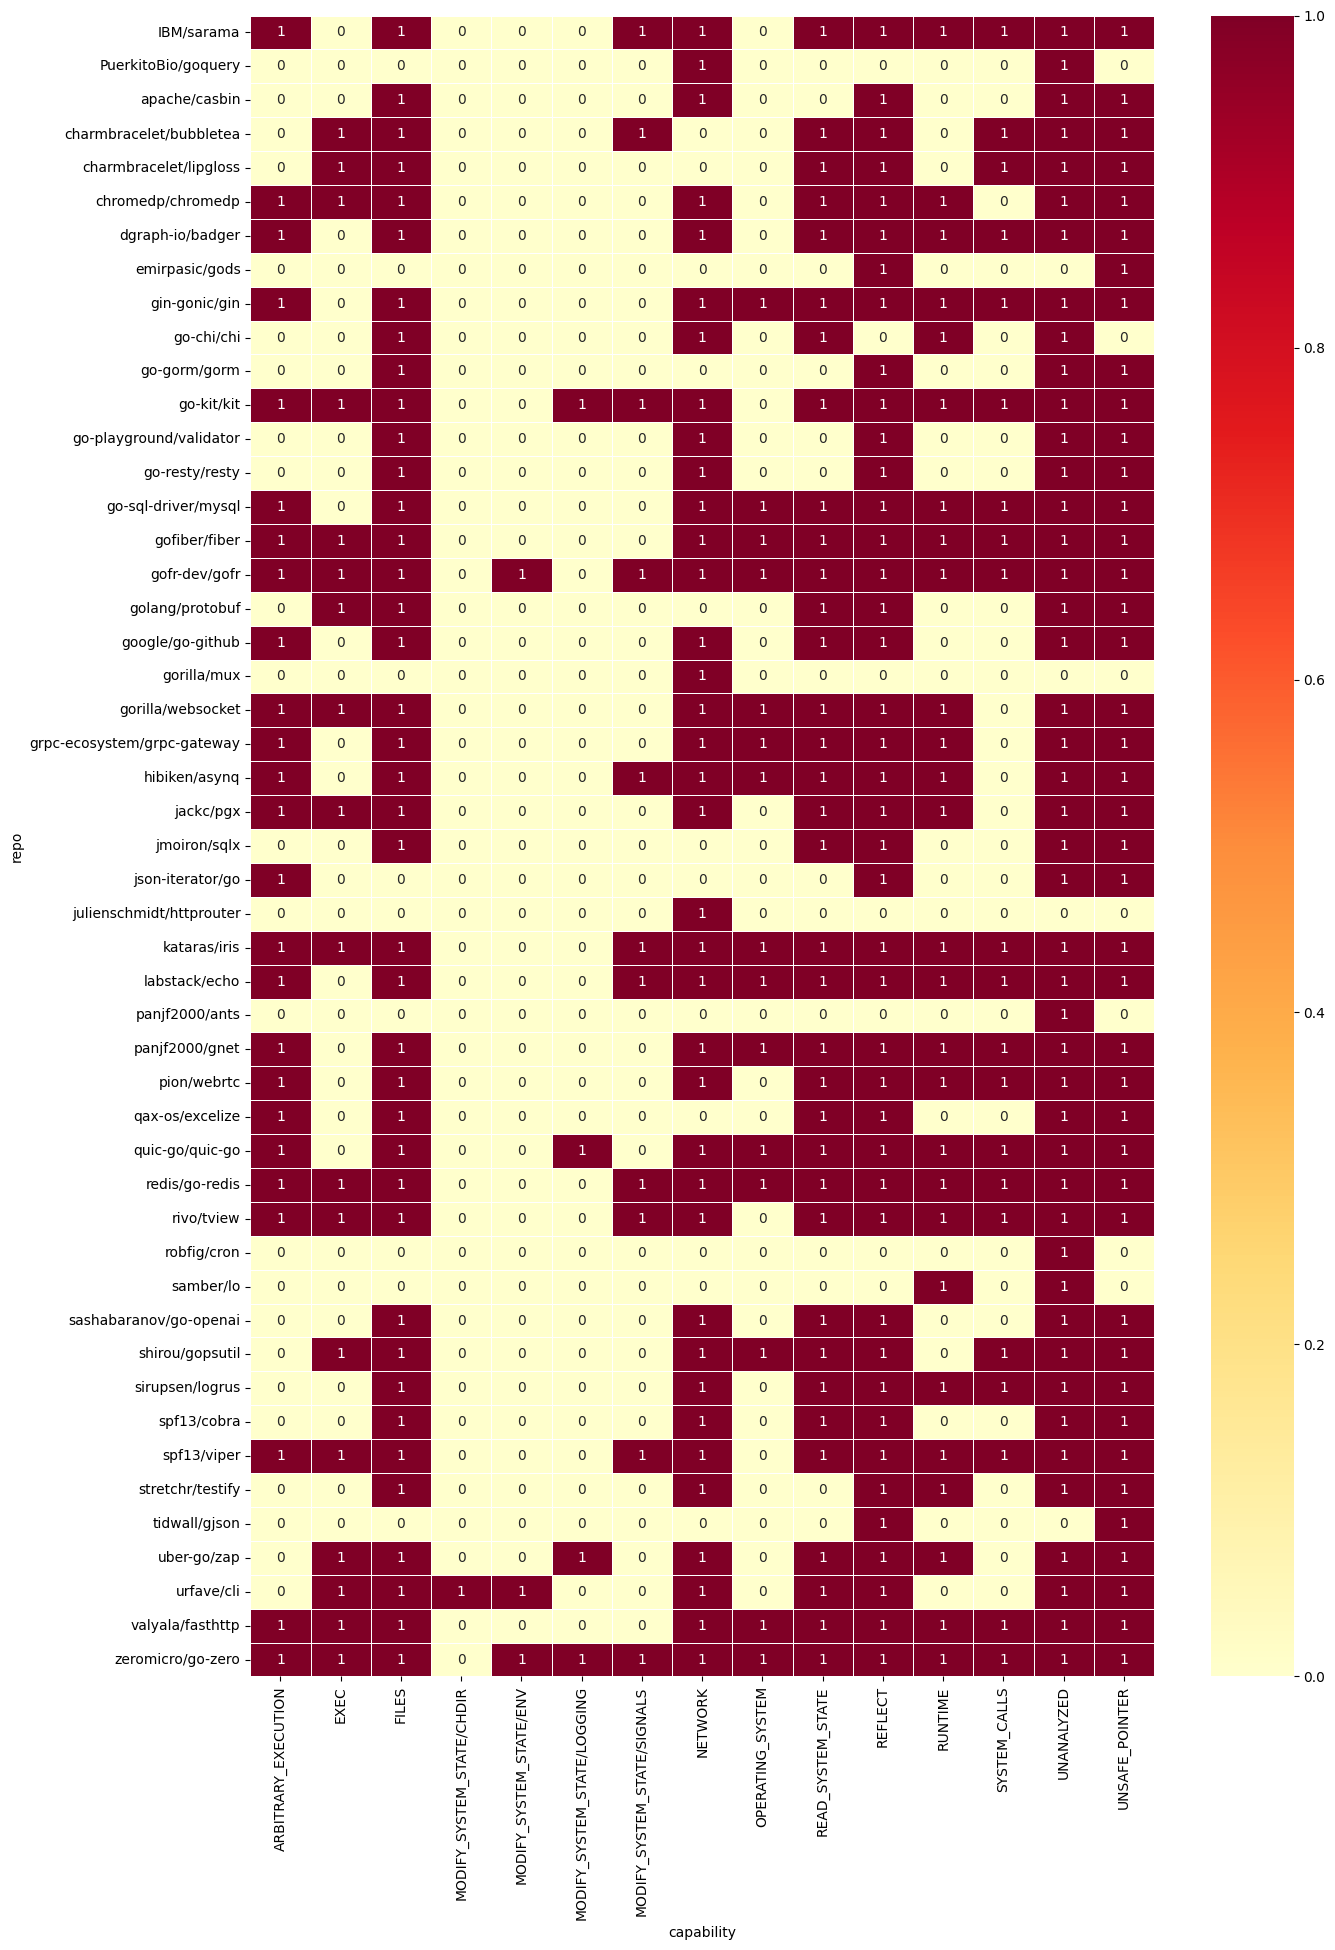

In [5]:
# pivot = df.groupby(["repo", "capability"]).size().unstack(fill_value=0)
pivot = (
    df.groupby(["repo", "capability"]).size().unstack(fill_value=0).gt(0).astype(int)
)

fig, ax = plt.subplots(figsize=(14, len(pivot) * 0.4))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.5, annot=True, fmt="d")
plt.tight_layout()
plt.show()